This dataset is on IPL(Indian Premier League) Cricket data from 2008 to 2024 taken from Kaggle.It contains 2 csv files: deliveries- contaning ball by ball for every over data and matches- overall details about the matches conducted in the season.

The primary objective is to use historical IPL data to build a predictive model for future match outcomes, demonstrating the application of machine learning techniques to sports data.



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df_del=pd.read_csv('/content/deliveries.csv')

In [ ]:
df_mat=pd.read_csv('/content/matches.csv')

# Data Analysis

In [ ]:
df_del.head(3)

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN


In [ ]:
df_del.tail(3)

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
260917,1426312,2,Kolkata Knight Riders,Sunrisers Hyderabad,10,1,VR Iyer,Shahbaz Ahmed,SS Iyer,1,0,1,NaN,0,NaN,NaN,NaN
260918,1426312,2,Kolkata Knight Riders,Sunrisers Hyderabad,10,2,SS Iyer,Shahbaz Ahmed,VR Iyer,1,0,1,NaN,0,NaN,NaN,NaN
260919,1426312,2,Kolkata Knight Riders,Sunrisers Hyderabad,10,3,VR Iyer,Shahbaz Ahmed,SS Iyer,1,0,1,NaN,0,NaN,NaN,NaN


In [ ]:
df_mat.head(3)

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar


In [ ]:
df_mat.tail(3)

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
1092,1426310,2024,Ahmedabad,2024-05-22,Eliminator,R Ashwin,"Narendra Modi Stadium, Ahmedabad",Royal Challengers Bengaluru,Rajasthan Royals,Rajasthan Royals,field,Rajasthan Royals,wickets,4.0,173.0,20.0,N,NaN,KN Ananthapadmanabhan,MV Saidharshan Kumar
1093,1426311,2024,Chennai,2024-05-24,Qualifier 2,Shahbaz Ahmed,"MA Chidambaram Stadium, Chepauk, Chennai",Sunrisers Hyderabad,Rajasthan Royals,Rajasthan Royals,field,Sunrisers Hyderabad,runs,36.0,176.0,20.0,N,NaN,Nitin Menon,VK Sharma
1094,1426312,2024,Chennai,2024-05-26,Final,MA Starc,"MA Chidambaram Stadium, Chepauk, Chennai",Sunrisers Hyderabad,Kolkata Knight Riders,Sunrisers Hyderabad,bat,Kolkata Knight Riders,wickets,8.0,114.0,20.0,N,NaN,J Madanagopal,Nitin Menon


In [ ]:
df_del.shape

(260920, 17)

In [ ]:
df_mat.shape

(1095, 20)

In [ ]:
df_del.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          260920 non-null  int64 
 1   inning            260920 non-null  int64 
 2   batting_team      260920 non-null  object
 3   bowling_team      260920 non-null  object
 4   over              260920 non-null  int64 
 5   ball              260920 non-null  int64 
 6   batter            260920 non-null  object
 7   bowler            260920 non-null  object
 8   non_striker       260920 non-null  object
 9   batsman_runs      260920 non-null  int64 
 10  extra_runs        260920 non-null  int64 
 11  total_runs        260920 non-null  int64 
 12  extras_type       14125 non-null   object
 13  is_wicket         260920 non-null  int64 
 14  player_dismissed  12950 non-null   object
 15  dismissal_kind    12950 non-null   object
 16  fielder           9354 non-null    obj

In [ ]:
df_mat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

In [ ]:
df_del.describe()

,match_id,inning,over,ball,batsman_runs,extra_runs,total_runs,is_wicket
count,2.609200e+05,260920.000000,260920.000000,260920.000000,260920.000000,260920.000000,260920.000000,260920.000000
mean,9.070665e+05,1.483531,9.197677,3.624486,1.265001,0.067806,1.332807,0.049632
std,3.679913e+05,0.502643,5.683484,1.814920,1.639298,0.343265,1.626416,0.217184
min,3.359820e+05,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,5.483340e+05,1.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000
50%,9.809670e+05,1.000000,9.000000,4.000000,1.000000,0.000000,1.000000,0.000000
75%,1.254066e+06,2.000000,14.000000,5.000000,1.000000,0.000000,1.000000,0.000000
max,1.426312e+06,6.000000,19.000000,11.000000,6.000000,7.000000,7.000000,1.000000


In [ ]:
df_mat.describe()

,id,result_margin,target_runs,target_overs
count,1.095000e+03,1076.000000,1092.000000,1092.000000
mean,9.048283e+05,17.259294,165.684066,19.759341
std,3.677402e+05,21.787444,33.427048,1.581108
min,3.359820e+05,1.000000,43.000000,5.000000
25%,5.483315e+05,6.000000,146.000000,20.000000
50%,9.809610e+05,8.000000,166.000000,20.000000
75%,1.254062e+06,20.000000,187.000000,20.000000
max,1.426312e+06,146.000000,288.000000,20.000000


In [ ]:
df_mat['venue'].unique()

array(['M Chinnaswamy Stadium',
       'Punjab Cricket Association Stadium, Mohali', 'Feroz Shah Kotla',
       'Wankhede Stadium', 'Eden Gardens', 'Sawai Mansingh Stadium',
       'Rajiv Gandhi International Stadium, Uppal',
       'MA Chidambaram Stadium, Chepauk', 'Dr DY Patil Sports Academy',
       'Newlands', "St George's Park", 'Kingsmead', 'SuperSport Park',
       'Buffalo Park', 'New Wanderers Stadium', 'De Beers Diamond Oval',
       'OUTsurance Oval', 'Brabourne Stadium',
       'Sardar Patel Stadium, Motera', 'Barabati Stadium',
       'Brabourne Stadium, Mumbai',
       'Vidarbha Cricket Association Stadium, Jamtha',
       'Himachal Pradesh Cricket Association Stadium', 'Nehru Stadium',
       'Holkar Cricket Stadium',
       'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium',
       'Subrata Roy Sahara Stadium',
       'Maharashtra Cricket Association Stadium',
       'Shaheed Veer Narayan Singh International Stadium',
       'JSCA International Stadium Complex', 'Sh

In [ ]:
df_del.isna().sum()

,0
match_id,0
inning,0
batting_team,0
bowling_team,0
over,0
ball,0
batter,0
bowler,0
non_striker,0
batsman_runs,0


In [ ]:
# Checking null values
df_mat.isna().sum()

,0
id,0
season,0
city,51
date,0
match_type,0
player_of_match,5
venue,0
team1,0
team2,0
toss_winner,0


**Problem Statement**: Predict the winner of an IPL match using match details such as teams, toss winner, toss decision, venue and match statistics.

**Target Column**: Winner[categorical]

Supervised Classification Problem

In [ ]:
#number of wickets taken in all seasons
len(df_del[df_del.is_wicket==1])

12950

**MATCHES DATASET**

In [ ]:
df_mat['date'] = pd.to_datetime(df_mat.date)
df_mat['year'] = pd.DatetimeIndex(df_mat.date).year
df_mat['month'] = pd.DatetimeIndex(df_mat.date).month
df_mat['day'] = pd.DatetimeIndex(df_mat.date).day
df_mat['weekday'] = pd.DatetimeIndex(df_mat.date).weekday

In [ ]:
df_mat = df_mat.drop(['season','date','month','day','weekday'], axis=1)
df_mat

,id,city,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2,year
0,335982,Bangalore,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen,2008
1,335983,Chandigarh,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri,2008
2,335984,Delhi,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar,2008
3,335985,Mumbai,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper,2008
4,335986,Kolkata,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan,2008
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1090,1426307,Hyderabad,League,Abhishek Sharma,"Rajiv Gandhi International Stadium, Uppal, Hyd...",Punjab Kings,Sunrisers Hyderabad,Punjab Kings,bat,Sunrisers Hyderabad,wickets,4.0,215.0,20.0,N,NaN,Nitin Menon,VK Sharma,2024
1091,1426309,Ahmedabad,Qualifier 1,MA Starc,"Narendra Modi Stadium, Ahmedabad",Sunrisers Hyderabad,Kolkata Knight Riders,Sunrisers Hyderabad,bat,Kolkata Knight Riders,wickets,8.0,160.0,20.0,N,NaN,AK Chaudhary,R Pandit,2024
1092,1426310,Ahmedabad,Eliminator,R Ashwin,"Narendra Modi Stadium, Ahmedabad",Royal Challengers Bengaluru,Rajasthan Royals,Rajasthan Royals,field,Rajasthan Royals,wickets,4.0,173.0,20.0,N,NaN,KN Ananthapadmanabhan,MV Saidharshan Kumar,2024
1093,1426311,Chennai,Qualifier 2,Shahbaz Ahmed,"MA Chidambaram Stadium, Chepauk, Chennai",Sunrisers Hyderabad,Rajasthan Royals,Rajasthan Royals,field,Sunrisers Hyderabad,runs,36.0,176.0,20.0,N,NaN,Nitin Menon,VK Sharma,2024


**DELIVERIES DATASET**

In [ ]:
# not important for prediction of winner and more than 95% null values
# extra and batsman runs not needed as we already have total runs which include both dropping else will lead to multicollinearity and data leakage
# non_striker dropped as we have batter column
df_del = df_del.drop(['extras_type','player_dismissed','dismissal_kind','fielder','extra_runs','batsman_runs','non_striker'], axis=1)
df_del

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,total_runs,is_wicket
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,1,0
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,0,0
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,1,0
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,0,0
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,0,0
...,...,...,...,...,...,...,...,...,...,...
260915,1426312,2,Kolkata Knight Riders,Sunrisers Hyderabad,9,5,SS Iyer,AK Markram,1,0
260916,1426312,2,Kolkata Knight Riders,Sunrisers Hyderabad,9,6,VR Iyer,AK Markram,1,0
260917,1426312,2,Kolkata Knight Riders,Sunrisers Hyderabad,10,1,VR Iyer,Shahbaz Ahmed,1,0
260918,1426312,2,Kolkata Knight Riders,Sunrisers Hyderabad,10,2,SS Iyer,Shahbaz Ahmed,1,0


# EDA

**MATCHES DATASET**

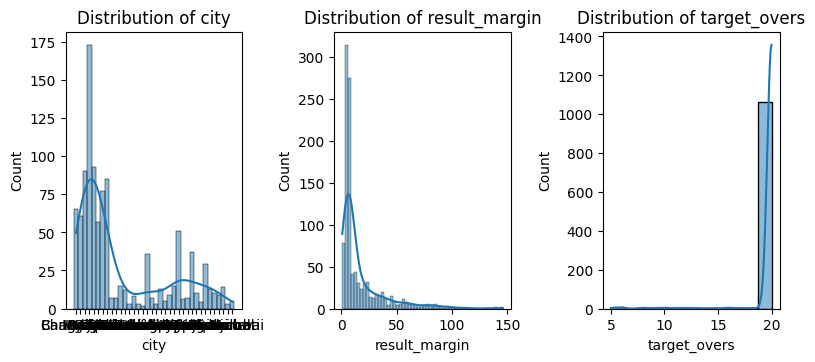

In [ ]:
columns=['city','result_margin','target_overs']
plt.figure(figsize=(8,10))
for i,col in enumerate(columns,1):
  plt.subplot(3,3,i)
  sns.histplot(df_mat[col],kde=True)
  plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Distribution of target_runs')

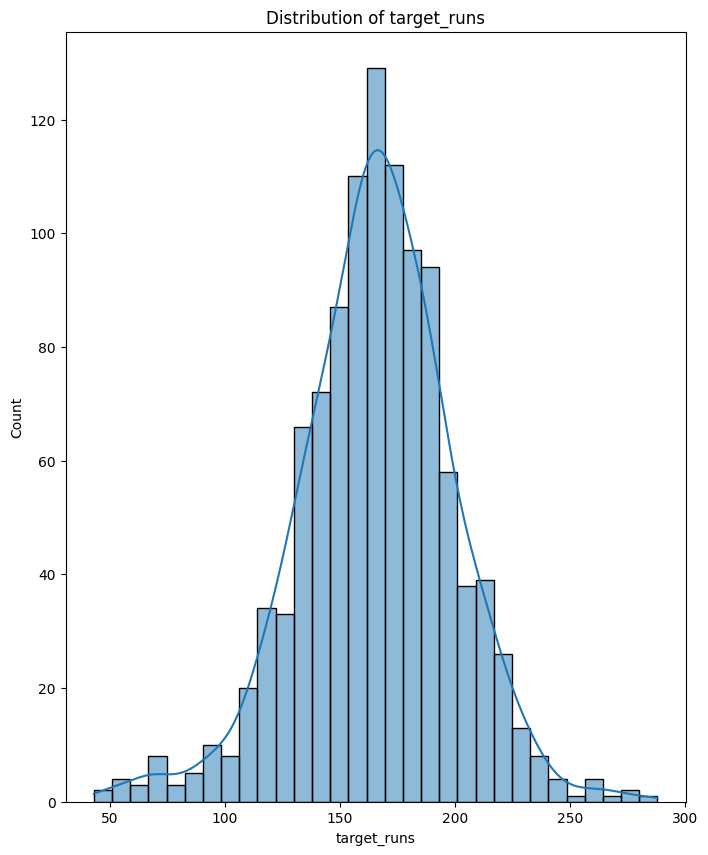

In [ ]:
plt.figure(figsize=(8,10))
sns.histplot(df_mat['target_runs'],kde=True)
plt.title('Distribution of target_runs')

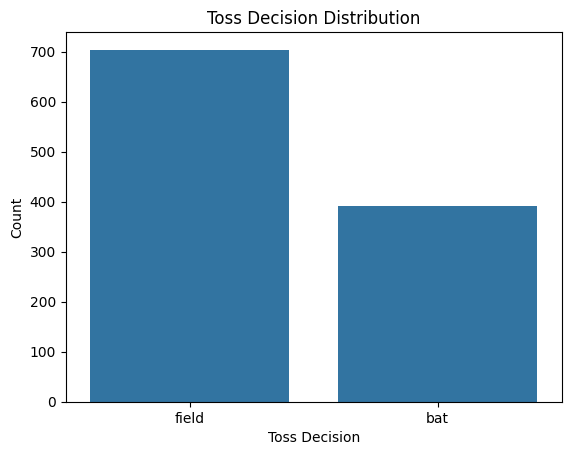

In [ ]:
sns.countplot(x=df_mat['toss_decision'])
plt.title("Toss Decision Distribution")
plt.xlabel("Toss Decision")
plt.ylabel("Count")
plt.show()

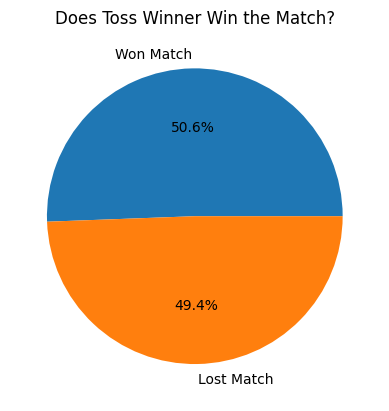

In [ ]:
toss_win_rate = (df_mat['toss_winner'] == df_mat['winner']).mean()

plt.pie([toss_win_rate, 1 - toss_win_rate],
        labels=['Won Match', 'Lost Match'],
        autopct='%1.1f%%')

plt.title("Does Toss Winner Win the Match?")
plt.show()

In [ ]:
df_mat['team1'] = df_mat['team1'].replace({
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Rising Pune Supergiants': 'Rising Pune Supergiant',
    'Royal Challengers Bangalore':'Royal Challengers Bengaluru'
})

df_mat['team2'] = df_mat['team2'].replace({
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Rising Pune Supergiants': 'Rising Pune Supergiant',
    'Royal Challengers Bangalore':'Royal Challengers Bengaluru'
})

df_mat['winner'] = df_mat['winner'].replace({
    'Delhi Daredevils':'Delhi Capitals',
    'Kings XI Punjab':'Punjab Kings',
    'Rising Pune Supergiants':'Rising Pune Supergiant',
    'Royal Challengers Bangalore':'Royal Challengers Bengaluru'
})

Text(0.5, 0, 'Teams')

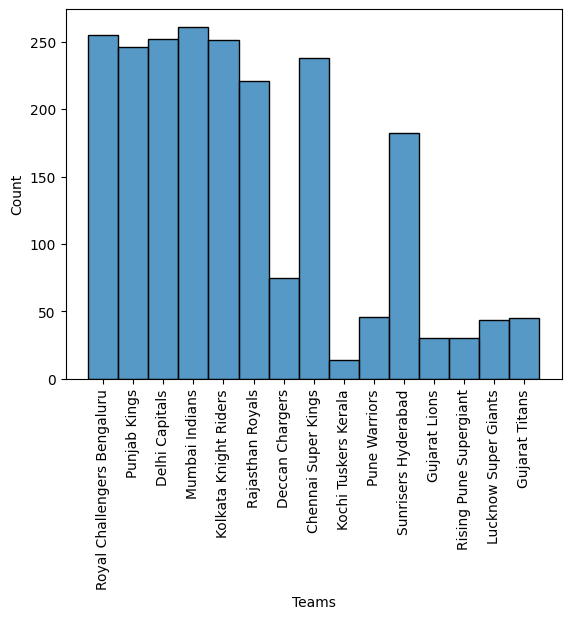

In [ ]:
#matches played by each team
played=list(df_mat['team1'])+list(df_mat['team2'])
sns.histplot(played)
plt.xticks(rotation=90)
plt.xlabel('Teams')

Text(0.5, 0, 'Teams')

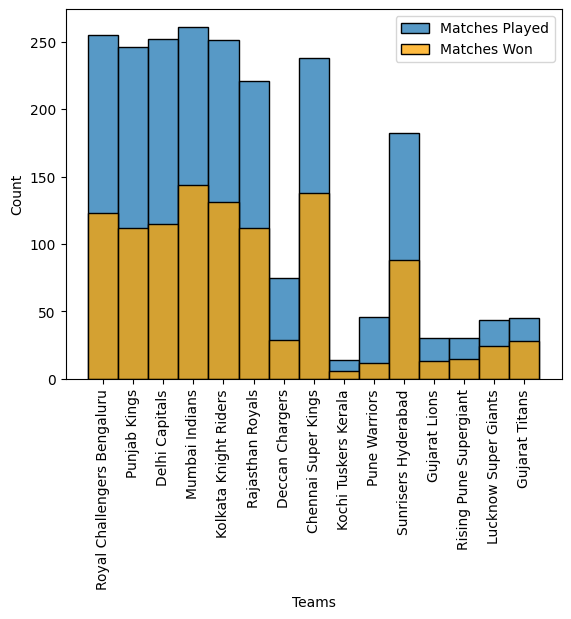

In [ ]:
#comparing the matches played and matches won by each team
sns.histplot(played)
sns.histplot(df_mat['winner'], color='orange')
plt.xticks(rotation=90)
plt.legend(['Matches Played','Matches Won'])
plt.xlabel('Teams')

In [ ]:
player_of_match=df_mat.player_of_match.value_counts().head(10)
player_of_match

,count
player_of_match,
AB de Villiers,25
CH Gayle,22
RG Sharma,19
V Kohli,18
DA Warner,18
MS Dhoni,17
YK Pathan,16
RA Jadeja,16
SR Watson,16


Text(0.5, 1.0, 'Player of the Match Award')

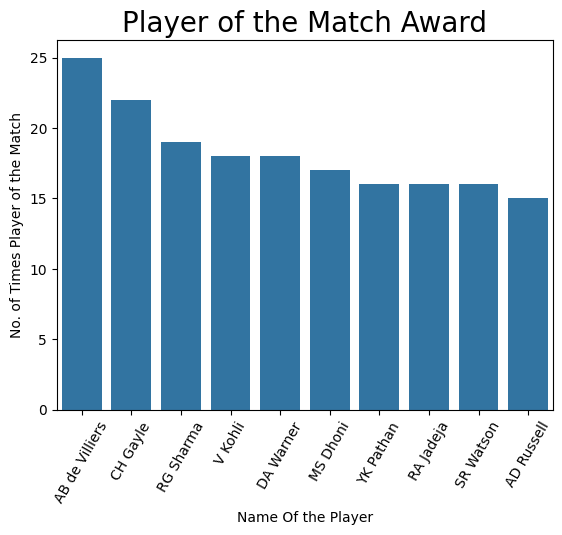

In [ ]:
sns.barplot(x=player_of_match.index, y=player_of_match.values)
plt.xticks(rotation=60)
plt.ylabel('No. of Times Player of the Match')
plt.xlabel('Name Of the Player')
plt.title('Player of the Match Award', fontsize=20)

Text(0.5, 1.0, 'Boxplot for result_margin')

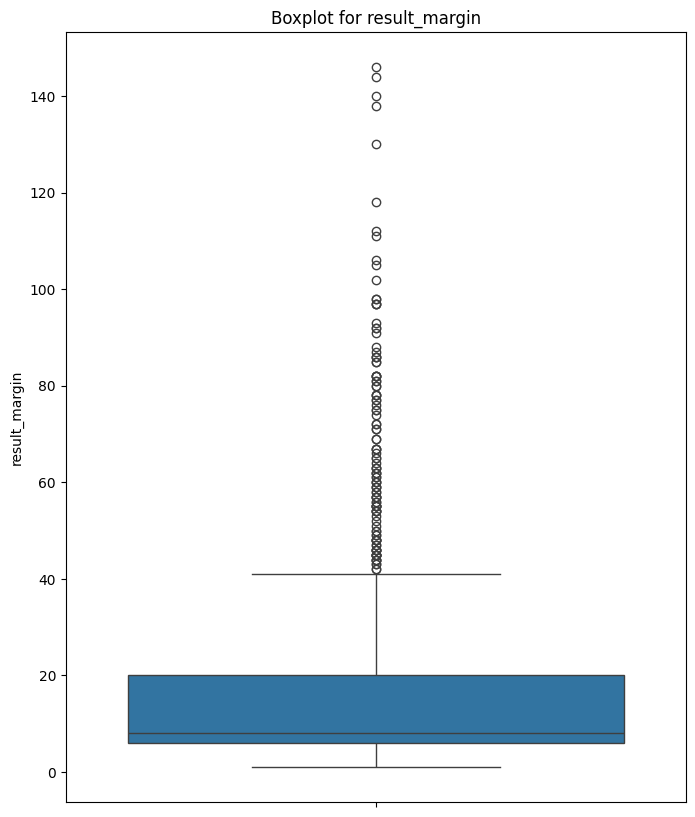

In [ ]:
# Outlier detection
plt.figure(figsize=(8,10))
sns.boxplot(df_mat['result_margin'])
plt.title('Boxplot for result_margin')

# Feature Engineering/ Preprocessing

**MATCHES DATASET**

In [ ]:
df_mat.columns

Index(['id', 'city', 'match_type', 'player_of_match', 'venue', 'team1',
       'team2', 'toss_winner', 'toss_decision', 'winner', 'result',
       'result_margin', 'target_runs', 'target_overs', 'super_over', 'method',
       'umpire1', 'umpire2', 'year'],
      dtype='object')

No need time progression so keeping year as it but not adding to num or cat cols.

In [ ]:
df_mat['toss_winner'].value_counts()

,count
toss_winner,
Mumbai Indians,143
Kolkata Knight Riders,122
Chennai Super Kings,122
Rajasthan Royals,120
Royal Challengers Bangalore,113
Sunrisers Hyderabad,88
Kings XI Punjab,85
Delhi Daredevils,80
Delhi Capitals,50


In [ ]:
df_mat['venue'] = df_mat['venue'].replace({
    'M.Chinnaswamy Stadium':'M Chinnaswamy Stadium',
    'M Chinnaswamy Stadium, Bengaluru':'M Chinnaswamy Stadium',
    'Wankhede Stadium, Mumbai':'Wankhede Stadium',
    'Eden Gardens, Kolkata':'Eden Gardens',
    'MA Chidambaram Stadium, Chepauk, Chennai':'MA Chidambaram Stadium',
    'MA Chidambaram Stadium, Chepauk':'MA Chidambaram Stadium'
})

In [ ]:
df_mat['venue'].value_counts()

,count
venue,
Wankhede Stadium,118
M Chinnaswamy Stadium,94
Eden Gardens,93
MA Chidambaram Stadium,85
Feroz Shah Kotla,60
"Rajiv Gandhi International Stadium, Uppal",49
Sawai Mansingh Stadium,47
Dubai International Cricket Stadium,46
"Punjab Cricket Association Stadium, Mohali",35


In [ ]:
df_mat['result'].value_counts()

,count
result,
wickets,578
runs,498
tie,14
no result,5


In [ ]:
df_mat['super_over'].value_counts()

,count
super_over,
N,1081
Y,14


In [ ]:
df_mat['method'].value_counts()

,count
method,
D/L,21


In [ ]:
df_mat['match_type'].value_counts()

,count
match_type,
League,1029
Final,17
Qualifier 2,14
Qualifier 1,14
Eliminator,11
Semi Final,6
Elimination Final,3
3rd Place Play-Off,1


In [ ]:
df_mat['umpire1'].value_counts()

,count
umpire1,
AK Chaudhary,115
HDPK Dharmasena,79
KN Ananthapadmanabhan,59
CB Gaffaney,53
Asad Rauf,51
...,...
K Srinivasan,2
Tapan Sharma,2
AG Wharf,2


In [ ]:
df_mat['umpire2'].value_counts()

,count
umpire2,
S Ravi,83
VK Sharma,61
C Shamshuddin,60
Nitin Menon,54
SJA Taufel,54
...,...
SJ Davis,1
JD Cloete,1
BF Bowden,1


In [ ]:
# Null Value Handling

# Categorical column,filling with mode value
df_mat['city']=df_mat['city'].fillna(df_mat['city'].mode()[0])
df_mat['player_of_match']=df_mat['player_of_match'].fillna(df_mat['player_of_match'].mode()[0])

# result_margin- numerical- right skewed- filling with median
df_mat['result_margin']=df_mat['result_margin'].fillna(df_mat['result_margin'].median())

# target_runs- numericl- normally distributed- filling with mean
df_mat['target_runs']=df_mat['target_runs'].fillna(df_mat['target_runs'].mean())

# target_overs- constant 20 overs
df_mat['target_overs'] = df_mat['target_overs'].fillna(20)

# method column almost 98% null value as D/L method used rarely- dropping
df_mat = df_mat.drop('method', axis=1)

# When tie winner has no result in it so dropping
df_mat = df_mat.dropna(subset=['winner'])

In [ ]:
df_mat = df_mat.drop(['result','umpire1','umpire2','player_of_match','team1','team2'], axis=1)

In [ ]:
# result- not useful as our target is already winner
# umpires- information not useful for winner prediction
# player of match- predicted after the match hence will mislead the model and expect for such a column to tell the prediction

In [ ]:
df_mat.columns

Index(['id', 'city', 'match_type', 'venue', 'toss_winner', 'toss_decision',
       'winner', 'result_margin', 'target_runs', 'target_overs', 'super_over',
       'year'],
      dtype='object')

Combining both the datasets

In [ ]:
match = df_mat.rename(columns={'id':'match_id'})
df = pd.merge(df_del,match, on='match_id')

In [ ]:
df

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,total_runs,is_wicket,...,match_type,venue,toss_winner,toss_decision,winner,result_margin,target_runs,target_overs,super_over,year
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,1,0,...,League,M Chinnaswamy Stadium,Royal Challengers Bangalore,field,Kolkata Knight Riders,140.0,223.0,20.0,N,2008
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,0,0,...,League,M Chinnaswamy Stadium,Royal Challengers Bangalore,field,Kolkata Knight Riders,140.0,223.0,20.0,N,2008
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,1,0,...,League,M Chinnaswamy Stadium,Royal Challengers Bangalore,field,Kolkata Knight Riders,140.0,223.0,20.0,N,2008
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,0,0,...,League,M Chinnaswamy Stadium,Royal Challengers Bangalore,field,Kolkata Knight Riders,140.0,223.0,20.0,N,2008
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,0,0,...,League,M Chinnaswamy Stadium,Royal Challengers Bangalore,field,Kolkata Knight Riders,140.0,223.0,20.0,N,2008
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260425,1426312,2,Kolkata Knight Riders,Sunrisers Hyderabad,9,5,SS Iyer,AK Markram,1,0,...,Final,MA Chidambaram Stadium,Sunrisers Hyderabad,bat,Kolkata Knight Riders,8.0,114.0,20.0,N,2024
260426,1426312,2,Kolkata Knight Riders,Sunrisers Hyderabad,9,6,VR Iyer,AK Markram,1,0,...,Final,MA Chidambaram Stadium,Sunrisers Hyderabad,bat,Kolkata Knight Riders,8.0,114.0,20.0,N,2024
260427,1426312,2,Kolkata Knight Riders,Sunrisers Hyderabad,10,1,VR Iyer,Shahbaz Ahmed,1,0,...,Final,MA Chidambaram Stadium,Sunrisers Hyderabad,bat,Kolkata Knight Riders,8.0,114.0,20.0,N,2024
260428,1426312,2,Kolkata Knight Riders,Sunrisers Hyderabad,10,2,SS Iyer,Shahbaz Ahmed,1,0,...,Final,MA Chidambaram Stadium,Sunrisers Hyderabad,bat,Kolkata Knight Riders,8.0,114.0,20.0,N,2024


Will take information from user for these columns and will transform it to these columns as model can predict accurately only with these columns and hence can drop the actual columns used to derive it which user enters.So in model deployment will ask from user but in the datframe not required.

In [ ]:
# only for chasing
df = df[df['inning'] == 2]

In [ ]:
# score upto that ball each time
df['current_score'] = df.groupby('match_id')['total_runs'].cumsum()

/tmp/ipykernel_19226/2925162160.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['current_score'] = df.groupby('match_id')['total_runs'].cumsum()


In [ ]:
df['runs_left'] = df['target_runs'] - df['current_score']

/tmp/ipykernel_19226/3358586885.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['runs_left'] = df['target_runs'] - df['current_score']


In [ ]:
df['balls_left'] = 120 - (df['over']*6 + df['ball'])

/tmp/ipykernel_19226/2623714606.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['balls_left'] = 120 - (df['over']*6 + df['ball'])


In [ ]:
df['wickets'] = df.groupby('match_id')['is_wicket'].cumsum()

/tmp/ipykernel_19226/496112776.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['wickets'] = df.groupby('match_id')['is_wicket'].cumsum()


In [ ]:
df['wickets_left'] = 10 - df['wickets']

/tmp/ipykernel_19226/1925908156.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['wickets_left'] = 10 - df['wickets']


In [ ]:
df['crr'] = df['current_score'] / ((df['over']*6 + df['ball'])/6)

/tmp/ipykernel_19226/743548541.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['crr'] = df['current_score'] / ((df['over']*6 + df['ball'])/6)


In [ ]:
df['rrr'] = (df['runs_left']*6) / df['balls_left']

/tmp/ipykernel_19226/488925425.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['rrr'] = (df['runs_left']*6) / df['balls_left']


In [ ]:
# batter and bowler does not directly influence the winner prediction
# its encoding leads to overfitting and mislead and since we have other important features dropping it
df=df.drop(['inning','over','ball','total_runs','is_wicket','wickets','batter','bowler'],axis=1)
df

,match_id,batting_team,bowling_team,city,match_type,venue,toss_winner,toss_decision,winner,result_margin,target_runs,target_overs,super_over,year,current_score,runs_left,balls_left,wickets_left,crr,rrr
124,335982,Royal Challengers Bangalore,Kolkata Knight Riders,Bangalore,League,M Chinnaswamy Stadium,Royal Challengers Bangalore,field,Kolkata Knight Riders,140.0,223.0,20.0,N,2008,1,222.0,119,10,6.000000,11.193277
125,335982,Royal Challengers Bangalore,Kolkata Knight Riders,Bangalore,League,M Chinnaswamy Stadium,Royal Challengers Bangalore,field,Kolkata Knight Riders,140.0,223.0,20.0,N,2008,2,221.0,118,10,6.000000,11.237288
126,335982,Royal Challengers Bangalore,Kolkata Knight Riders,Bangalore,League,M Chinnaswamy Stadium,Royal Challengers Bangalore,field,Kolkata Knight Riders,140.0,223.0,20.0,N,2008,2,221.0,117,10,4.000000,11.333333
127,335982,Royal Challengers Bangalore,Kolkata Knight Riders,Bangalore,League,M Chinnaswamy Stadium,Royal Challengers Bangalore,field,Kolkata Knight Riders,140.0,223.0,20.0,N,2008,3,220.0,116,10,4.500000,11.379310
128,335982,Royal Challengers Bangalore,Kolkata Knight Riders,Bangalore,League,M Chinnaswamy Stadium,Royal Challengers Bangalore,field,Kolkata Knight Riders,140.0,223.0,20.0,N,2008,4,219.0,115,10,4.800000,11.426087
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260425,1426312,Kolkata Knight Riders,Sunrisers Hyderabad,Chennai,Final,MA Chidambaram Stadium,Sunrisers Hyderabad,bat,Kolkata Knight Riders,8.0,114.0,20.0,N,2024,110,4.0,61,8,11.186441,0.393443
260426,1426312,Kolkata Knight Riders,Sunrisers Hyderabad,Chennai,Final,MA Chidambaram Stadium,Sunrisers Hyderabad,bat,Kolkata Knight Riders,8.0,114.0,20.0,N,2024,111,3.0,60,8,11.100000,0.300000
260427,1426312,Kolkata Knight Riders,Sunrisers Hyderabad,Chennai,Final,MA Chidambaram Stadium,Sunrisers Hyderabad,bat,Kolkata Knight Riders,8.0,114.0,20.0,N,2024,112,2.0,59,8,11.016393,0.203390
260428,1426312,Kolkata Knight Riders,Sunrisers Hyderabad,Chennai,Final,MA Chidambaram Stadium,Sunrisers Hyderabad,bat,Kolkata Knight Riders,8.0,114.0,20.0,N,2024,113,1.0,58,8,10.935484,0.103448


In [ ]:
# this feature is taken after the match is over and can lead to overfitting hence removing
df=df.drop('result_margin',axis=1)
df.columns

Index(['match_id', 'batting_team', 'bowling_team', 'city', 'match_type',
       'venue', 'toss_winner', 'toss_decision', 'winner', 'target_runs',
       'target_overs', 'super_over', 'year', 'current_score', 'runs_left',
       'balls_left', 'wickets_left', 'crr', 'rrr'],
      dtype='object')

In [ ]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

In [ ]:
num_cols

Index(['match_id', 'target_runs', 'target_overs', 'current_score', 'runs_left',
       'balls_left', 'wickets_left', 'crr', 'rrr'],
      dtype='object')

In [ ]:
# no need to scale these features
num_cols_new=num_cols.drop(['match_id','target_overs'])
num_cols_new

Index(['target_runs', 'current_score', 'runs_left', 'balls_left',
       'wickets_left', 'crr', 'rrr'],
      dtype='object')

In [ ]:
cat_cols

Index(['batting_team', 'bowling_team', 'city', 'match_type', 'venue',
       'toss_winner', 'toss_decision', 'winner', 'super_over'],
      dtype='object')

In [ ]:
# target will label encode
cat_cols=cat_cols.drop('winner')
cat_cols

Index(['batting_team', 'bowling_team', 'city', 'match_type', 'venue',
       'toss_winner', 'toss_decision', 'super_over'],
      dtype='object')

**Encoding and Standardization**

In [ ]:
df['rrr'] = (df['runs_left']*6) / df['balls_left']
df['rrr'] = df['rrr'].replace([np.inf, -np.inf], 0)
df['rrr'] = df['rrr'].fillna(0)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder

preprocessor= ColumnTransformer(transformers=[
    ('num',StandardScaler(),num_cols_new),
    ('cat',OneHotEncoder(),cat_cols)
    ])

In [ ]:
label_encoder= LabelEncoder()
df['winner']=label_encoder.fit_transform(df['winner'])

In [ ]:
from sklearn.model_selection import train_test_split

match_ids = df['match_id'].unique()

train_ids, test_ids = train_test_split(match_ids, test_size=0.2, random_state=42)

train = df[df['match_id'].isin(train_ids)]
test = df[df['match_id'].isin(test_ids)]

X_train = train.drop('winner', axis=1)
y_train = train['winner']

X_test = test.drop('winner', axis=1)
y_test = test['winner']

# Model Selection

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

pipeline=Pipeline(steps=[
    ("preprocessor",preprocessor),
    ("classifier",LogisticRegression(max_iter=1000))
])

# maximum number of iterations the model is allowed to run while trying to find the best parameters.
# It improves the weights step by step using optimization algorithms
# weights are the importance values the model assigns to each feature to make a prediction.How strongly each input feature affects the final prediction.
# weights are calculated using gradient descent–type optimization
# model starts with random weights
# z=w1​x1​+w2​x2​+...+b
# P(win)=1/1+e^-z

In [ ]:
pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['target_runs', 'current_score', 'runs_left', 'balls_left',
       'wickets_left', 'crr', 'rrr'],
      dtype='object')),
                                                 ('cat', OneHotEncoder(),
                                                  Index(['batting_team', 'bowling_team', 'city', 'match_type', 'venue',
       'toss_winner', 'toss_decision', 'super_over'],
      dtype='object'))])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [ ]:
y_pred_lr=pipeline.predict(X_test)

In [ ]:
pipeline2=Pipeline(steps=[
    ("preprocessor",preprocessor),
    ("classifier2",SVC())
])

In [ ]:
pipeline2.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['target_runs', 'current_score', 'runs_left', 'balls_left',
       'wickets_left', 'crr', 'rrr'],
      dtype='object')),
                                                 ('cat', OneHotEncoder(),
                                                  Index(['batting_team', 'bowling_team', 'city', 'match_type', 'venue',
       'toss_winner', 'toss_decision', 'super_over'],
      dtype='object'))])),
                ('classifier2', SVC())])

In [ ]:
y_pred_svc=pipeline2.predict(X_test)

In [ ]:
pipeline3=Pipeline(steps=[
    ("preprocessor",preprocessor),
    ("classifier3",KNeighborsClassifier(n_neighbors=5))
])

In [ ]:
pipeline3.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['target_runs', 'current_score', 'runs_left', 'balls_left',
       'wickets_left', 'crr', 'rrr'],
      dtype='object')),
                                                 ('cat', OneHotEncoder(),
                                                  Index(['batting_team', 'bowling_team', 'city', 'match_type', 'venue',
       'toss_winner', 'toss_decision', 'super_over'],
      dtype='object'))])),
                ('classifier3', KNeighborsClassifier())])

In [ ]:
y_pred_knn=pipeline3.predict(X_test)

In [ ]:
pipeline4=Pipeline(steps=[
    ("preprocessor",preprocessor),
    ("classifier4",DecisionTreeClassifier())
])

In [ ]:
pipeline4.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['target_runs', 'current_score', 'runs_left', 'balls_left',
       'wickets_left', 'crr', 'rrr'],
      dtype='object')),
                                                 ('cat', OneHotEncoder(),
                                                  Index(['batting_team', 'bowling_team', 'city', 'match_type', 'venue',
       'toss_winner', 'toss_decision', 'super_over'],
      dtype='object'))])),
                ('classifier4', DecisionTreeClassifier())])

In [ ]:
y_pred_dt=pipeline4.predict(X_test)

In [ ]:
pipeline5=Pipeline(steps=[
    ("preprocessor",preprocessor),
    ("classifier5",RandomForestClassifier())
])

In [ ]:
pipeline5.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['target_runs', 'current_score', 'runs_left', 'balls_left',
       'wickets_left', 'crr', 'rrr'],
      dtype='object')),
                                                 ('cat', OneHotEncoder(),
                                                  Index(['batting_team', 'bowling_team', 'city', 'match_type', 'venue',
       'toss_winner', 'toss_decision', 'super_over'],
      dtype='object'))])),
                ('classifier5', RandomForestClassifier())])

In [ ]:
y_pred_rf=pipeline5.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

a_lr=accuracy_score(y_test,y_pred_lr)
a_svc=accuracy_score(y_test,y_pred_svc)
a_knn=accuracy_score(y_test,y_pred_knn)
a_dt=accuracy_score(y_test,y_pred_dt)
a_rf=accuracy_score(y_test,y_pred_rf)

p_lr=precision_score(y_test,y_pred_lr,average='weighted')
p_svc=precision_score(y_test,y_pred_svc,average='weighted')
p_knn=precision_score(y_test,y_pred_knn,average='weighted')
p_dt=precision_score(y_test,y_pred_dt,average='weighted')
p_rf=precision_score(y_test,y_pred_rf,average='weighted')

r_lr=recall_score(y_test,y_pred_lr,average='macro')
r_svc=recall_score(y_test,y_pred_svc,average='macro')
r_knn=recall_score(y_test,y_pred_knn,average='macro')
r_dt=recall_score(y_test,y_pred_dt,average='macro')
r_rf=recall_score(y_test,y_pred_rf,average='macro')

f1_lr=f1_score(y_test,y_pred_lr,average='weighted')
f1_svc=f1_score(y_test,y_pred_svc,average='weighted')
f1_knn=f1_score(y_test,y_pred_knn,average='weighted')
f1_dt=f1_score(y_test,y_pred_dt,average='weighted')
f1_rf=f1_score(y_test,y_pred_rf,average='weighted')

results_df=pd.DataFrame({
    'Model':['Logistic Regression','KNN','SVC','Decision Tree','Random Forest'],
    'Accuracy Score':[a_lr,a_svc,a_knn,a_dt,a_rf],
    'Precision':[p_lr,p_svc,p_knn,p_dt,p_rf],
    'Recall Score':[r_lr,r_svc,r_knn,r_dt,r_rf],
    'F1 Score':[f1_lr,f1_svc,f1_knn,f1_dt,f1_rf],
    })

results_df

# Average=weighted is used since multiclass many labels
# average=macro to avoid being same as accuracy. In this recall is calculated per class and averaged

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Model,Accuracy Score,Precision,Recall Score,F1 Score
0,Logistic Regression,0.512647,0.531176,0.440330,0.512127
1,KNN,0.644681,0.664111,0.628941,0.647376
2,SVC,0.497035,0.509248,0.520180,0.494768
3,Decision Tree,0.567792,0.586621,0.518614,0.566594
4,Random Forest,0.581669,0.584071,0.504473,0.571497


- KNN is the best model as it has an accuracy of 64.4681% which means the model predicts winner with its actual winner by studying data with this percent of accuracy.
- 62.8941% of predicted wins are correct.
- Model detects 64.4681% of real wins.
- Overall balance F1 score=64.7376

In [ ]:
import pickle
pickle_model_path="sports.pkl"
with open(pickle_model_path,"wb") as f:
  pickle.dump(pipeline3,f)